<a href="https://colab.research.google.com/github/A01801224/TC3009C-RI/blob/main/Reto_Primer_Avance_Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto: Primer Avance
## Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

---

## Objetivo del notebook

Este notebook documenta el primer avance del reto **Spaceship Titanic**, enfocado estrictamente en la preparación y limpieza de los datos. El proceso abarca desde la carga inicial y el análisis exploratorio (EDA), hasta la selección de variables, el manejo de datos faltantes y las transformaciones matemáticas necesarias (codificación, corrección de sesgo y escalado) para dejar el conjunto de entrenamiento listo para una futura fase de modelado.

El notebook está organizado estrictamente bajo el siguiente esquema:

1. Carga y comprensión del dataset
2. Análisis Exploratorio de Datos (EDA)
3. Selección y descarte de variables
4. Manejo de faltantes
5. Codificación de variables categóricas
6. Transformación de variables numéricas y Escalado
7. Verificación final y Conclusión

**Nota sobre la metodología:** En cumplimiento con los requerimientos de esta primera entrega, el alcance de este documento concluye en la verificación final del dataset procesado (excluyendo el entrenamiento de modelos o la predicción sobre el conjunto de prueba). Asimismo, las tareas de *Feature Engineering* (como la extracción de componentes de la cabina y el tamaño de grupo) se han integrado de forma fluida al inicio de la fase de preprocesamiento, garantizando así un tratamiento lógico de los valores nulos antes de aplicar cualquier codificación o escalado.

# 1. Carga y Comprensión del Dataset

## 1.1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1.2. Carga de datos

Cargamos `train.csv` y `test.csv` usando rutas relativas (`../data/`), de manera que
el notebook pueda ejecutarse en cualquier equipo o entorno sin depender de una URL
externa a un repositorio de GitHub.

In [2]:
DATA = Path("..") / "data"
df_train = pd.read_csv(DATA / "train.csv")
df_test = pd.read_csv(DATA / "test.csv")

print("train:", df_train.shape)
print("test :", df_test.shape)

train: (8693, 14)
test : (4277, 13)


**Nota sobre `test.csv`:** se carga únicamente como referencia, para conservar la
misma estructura de variables desde el inicio. En este primer avance, todo el EDA,
la selección de variables y las decisiones de preprocesamiento se realizan
exclusivamente con `train.csv`, ya que es el único conjunto que contiene la variable
objetivo `Transported`. En la Sección 7 aplicamos exactamente las mismas
transformaciones — ajustadas únicamente con estadísticas de `train.csv` — sobre
`test.csv`.

## 1.3. Inspección inicial y tipos de datos

In [3]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
print("Tipo de dato de 'Transported':", df_train["Transported"].dtype)
print("Valores únicos de 'Transported':", df_train["Transported"].unique())

Tipo de dato de 'Transported': bool
Valores únicos de 'Transported': [False  True]


`Transported` es una variable booleana con dos posibles valores (`True`/`False`), por
lo que **Spaceship Titanic es un problema de clasificación binaria**: buscamos
predecir si cada pasajero fue o no transportado a otra dimensión durante el incidente.

# 2. Análisis Exploratorio de Datos (EDA)

## 2.1. Resumen estadístico general

Antes de explorar variable por variable, obtenemos una vista general del dataset:
estadísticas descriptivas de las columnas numéricas y un primer vistazo a los valores
faltantes. Revisar los nulos desde este punto — y no hasta el final del EDA — nos
permite tenerlos presentes durante todo el análisis univariable y bivariable que
sigue; la clasificación detallada de *por qué* faltan estos datos (informativos vs.
reales) se retoma con más profundidad en la Sección 2.4.

In [6]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [7]:
nulos_abs = df_train.isnull().sum()
nulos_pct = (df_train.isnull().mean() * 100).round(2)

resumen_nulos = pd.DataFrame({"nulos": nulos_abs, "porcentaje": nulos_pct})
resumen_nulos.sort_values("porcentaje", ascending=False)

,nulos,porcentaje
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


Todas las columnas con datos faltantes rondan entre el 2.0% y el 2.5% de nulos.
Ninguna variable supera un umbral crítico que justifique descartarla únicamente por
volumen de datos faltantes; el tratamiento específico de cada una se decide más
adelante según su naturaleza (Sección 2.4 y Sección 3.1).

## 2.2. Análisis univariable

Antes de explorar distribuciones necesitamos definir explícitamente los grupos de
variables que usaremos en el resto del notebook. Definir `num_cols`, `cat_cols`,
`spend_cols` e `id_cols` aquí, antes de cualquier celda de crosstabs o boxplots,
evita errores de ejecución por dependencia de orden entre celdas.

In [8]:
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
id_cols = ["PassengerId", "Cabin", "Name"]

print("Categóricas :", cat_cols)
print("Numéricas   :", num_cols)
print("De gasto    :", spend_cols)
print("Identificadores/texto:", id_cols)

Categóricas : ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
Numéricas   : ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
De gasto    : ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Identificadores/texto: ['PassengerId', 'Cabin', 'Name']


**Clasificación inicial de variables**

- **Categóricas** (baja cardinalidad, útiles para agrupación y proporciones):
  `HomePlanet`, `CryoSleep`, `Destination`, `VIP`, y `Transported` (variable objetivo).
- **Numéricas continuas** (distribuciones, asimetría y presencia de outliers):
  `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.
- **Identificadores y texto** (requieren extracción de información antes de poder
  usarse como predictores): `PassengerId`, `Cabin`, `Name`.

Esta clasificación es un punto de partida; se refina conforme avanza el EDA.

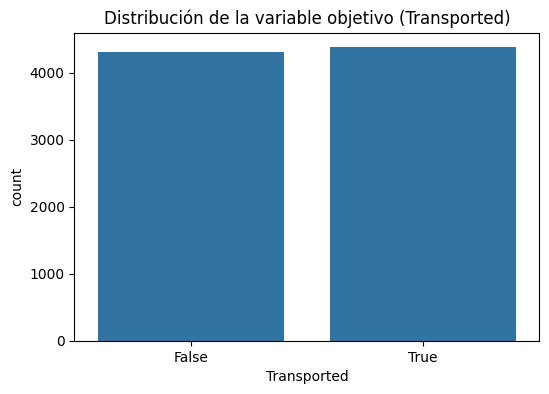

Transported
True     50.4
False    49.6
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x="Transported")
plt.title("Distribución de la variable objetivo (Transported)")
plt.show()

print(df_train["Transported"].value_counts(normalize=True).round(3) * 100)

La clase objetivo está prácticamente balanceada (aproximadamente 50.4% `True` vs.
49.6% `False`), por lo que no es necesario aplicar técnicas de balanceo de clases
(como sobremuestreo o submuestreo) y la exactitud (*accuracy*) es una métrica de
evaluación razonable para este problema.

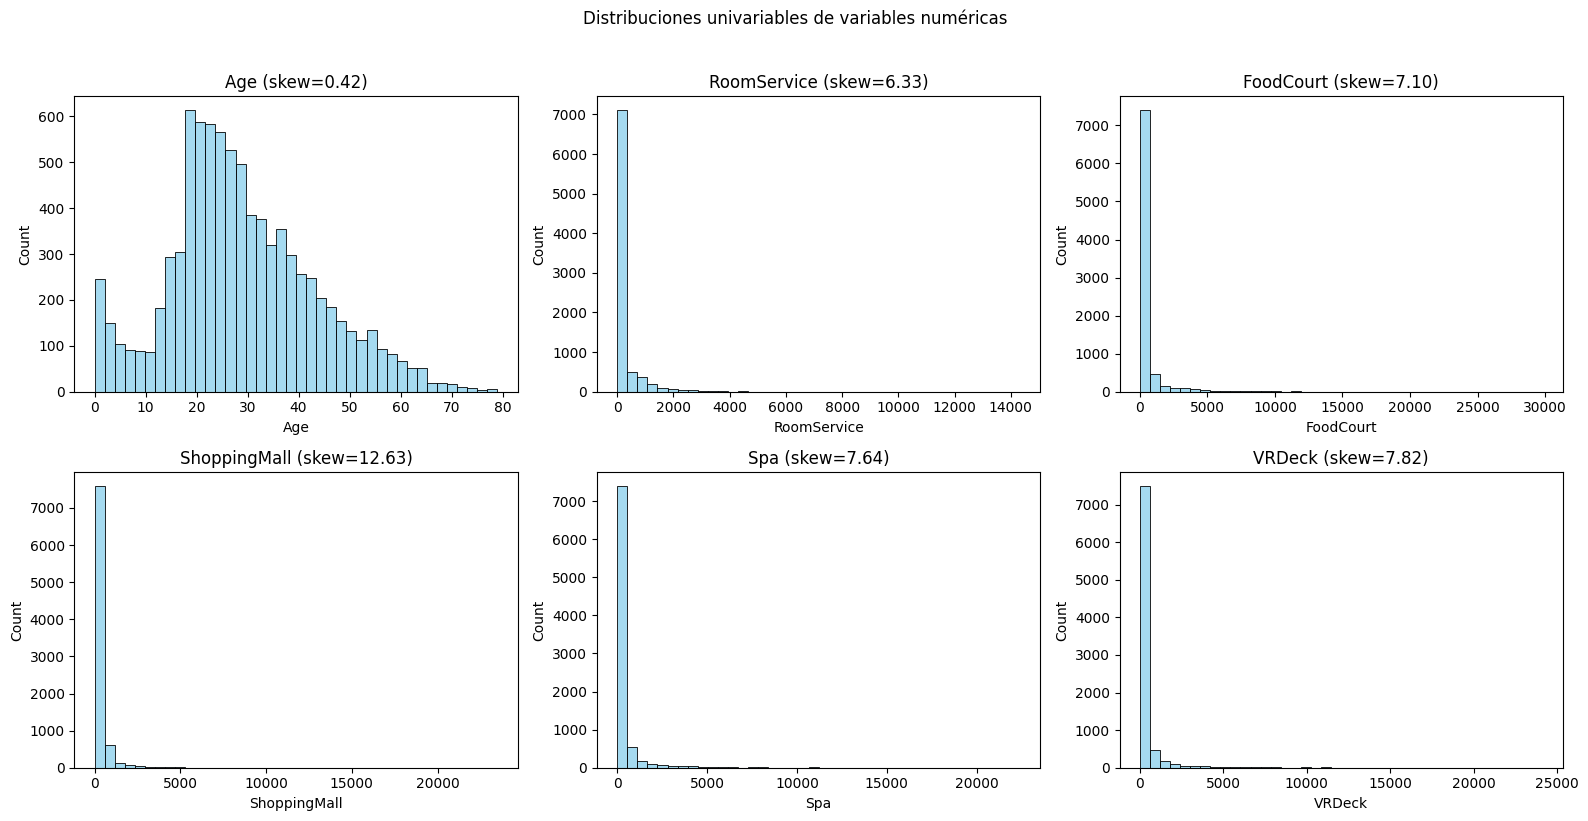

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df_train[col].dropna(), bins=40, ax=ax, color="skyblue")
    ax.set_title(f"{col} (skew={df_train[col].skew():.2f})")
fig.suptitle("Distribuciones univariables de variables numéricas", y=1.02)
fig.tight_layout()
plt.show()

Al analizar la distribución de las variables numéricas encontramos dos
comportamientos muy distintos. `Age` tiene un *skewness* de aproximadamente 0.4, lo
que indica una distribución prácticamente simétrica, sin necesidad de una
transformación de sesgo. En cambio, las cinco variables de gasto (`RoomService`,
`FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) presentan un *skewness* muy alto (entre
6 y 13 según la variable), producto de que la mayoría de los pasajeros gastó \$0 en
ese servicio y una minoría gastó montos muy grandes; esta concentración masiva en
cero es, en sí misma, información relevante y la retomamos en la Sección 2.3 y en la
Sección 4.2.

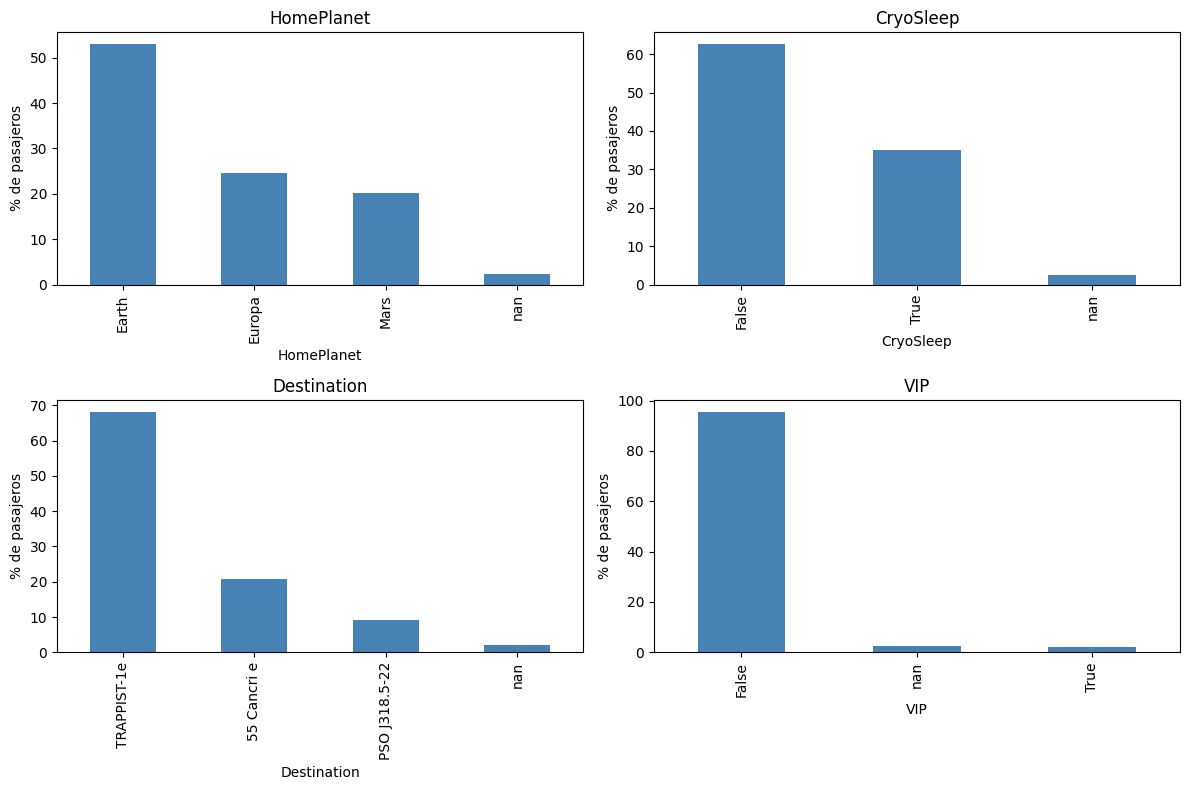

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    (df_train[col].value_counts(normalize=True, dropna=False) * 100).plot(
        kind="bar", ax=ax, color="steelblue"
    )
    ax.set_title(col)
    ax.set_ylabel("% de pasajeros")
fig.tight_layout()
plt.show()

Al revisar la distribución de las variables categóricas encontramos niveles de
desbalance muy distintos entre ellas. `HomePlanet` y `Destination` están
razonablemente repartidas entre sus categorías (Tierra ~53% / Europa ~25% / Marte
~20%, y TRAPPIST-1e ~68% / 55 Cancri e ~21% / PSO J318.5-22 ~9%, respectivamente).
`CryoSleep` está más balanceada (~65% `False` / ~35% `True`). En cambio, `VIP`
presenta un desbalance muy grande: más del 95% de los pasajeros no son VIP, apenas
alrededor de un 2% sí lo son y el resto son nulos. Esta baja variabilidad hace que
`VIP` aporte poca capacidad discriminativa; retomamos esta decisión al seleccionar
variables en la Sección 3.

## 2.3. Análisis bivariable (Variables vs. `Transported`)

Cruzamos cada variable categórica y numérica contra la variable objetivo para
identificar cuáles muestran una relación clara con `Transported`.

In [12]:
for col in cat_cols:
    print(f"\n--- {col} vs Transported ---")
    print(
        pd.crosstab(df_train[col], df_train["Transported"], normalize="index").round(3)
    )


--- HomePlanet vs Transported ---
Transported  False  True 
HomePlanet               
Earth        0.576  0.424
Europa       0.341  0.659
Mars         0.477  0.523

--- CryoSleep vs Transported ---
Transported  False  True 
CryoSleep                
False        0.671  0.329
True         0.182  0.818

--- Destination vs Transported ---
Transported    False  True 
Destination                
55 Cancri e    0.390  0.610
PSO J318.5-22  0.496  0.504
TRAPPIST-1e    0.529  0.471

--- VIP vs Transported ---
Transported  False  True 
VIP                      
False        0.494  0.506
True         0.618  0.382


`CryoSleep` es, por mucho, la variable categórica con la relación más fuerte: los
pasajeros en animación suspendida son transportados en una proporción mucho mayor que
los despiertos. `HomePlanet` y `Destination` también muestran diferencias notables
entre categorías. `VIP`, en cambio, apenas discrimina entre las dos clases —
consistente con lo observado en el análisis univariable — lo que refuerza la decisión
de no conservarla como predictor.

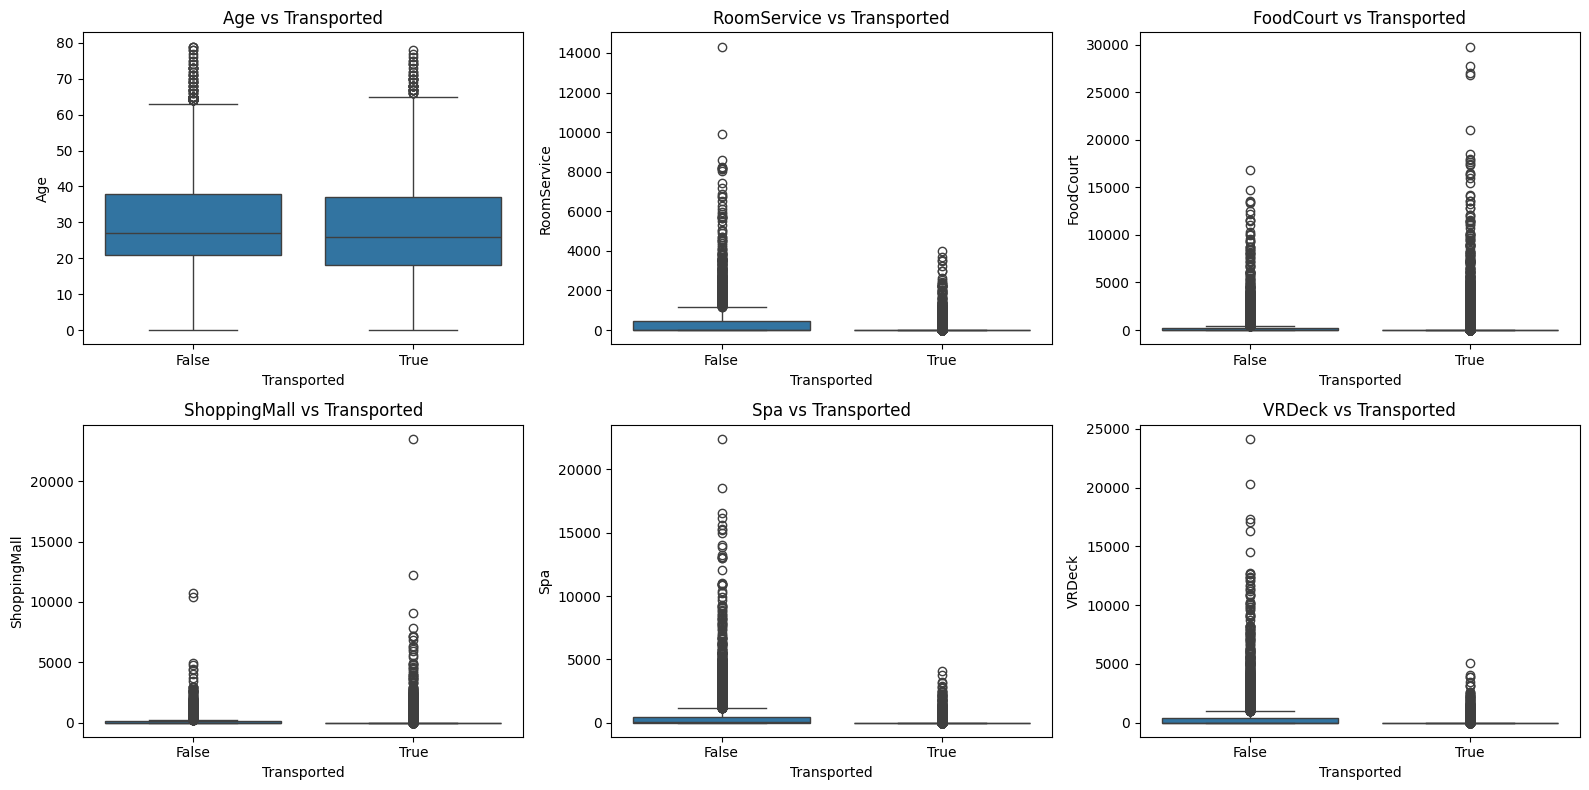

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df_train, x="Transported", y=col, ax=ax)
    ax.set_title(f"{col} vs Transported")
fig.tight_layout()
plt.show()

Para `Age` la diferencia entre grupos es modesta: los pasajeros más jóvenes (niños)
muestran una ligera mayor probabilidad de ser transportados. Para las variables de
gasto la relación es mucho más marcada: los pasajeros transportados tienden a
concentrarse en montos de gasto muy bajos o iguales a cero, mientras que los que
gastaron montos altos en `RoomService`, `Spa` o `VRDeck` tienden a **no** ser
transportados. Esto sugiere que el patrón "gastó vs. no gastó" podría ser tan
informativo como el monto exacto — hipótesis que evaluamos a continuación.

In [14]:
gasto_total_temp = df_train[spend_cols].sum(axis=1, min_count=1)
has_spent_temp = np.where(gasto_total_temp.isna(), np.nan, (gasto_total_temp > 0).astype(float))

print(
    pd.crosstab(
        pd.Series(has_spent_temp, name="HasSpent (exploratorio)"),
        df_train["Transported"],
        normalize="index",
    ).round(3)
)

Transported              False  True 
HasSpent (exploratorio)              
0.0                      0.214  0.786
1.0                      0.701  0.299


La comparación confirma que el patrón binario "gasto cero vs. gasto positivo" está
fuertemente asociado con `Transported`: los pasajeros que no gastaron nada tienen una
probabilidad mucho mayor de haber sido transportados que quienes sí consumieron algún
servicio. Esta variable binaria se **crea de forma definitiva más adelante, en la
Sección 4.2** (aquí solo se calcula de forma exploratoria, en una variable temporal,
para no adelantar la ingeniería de características). Aun así, decidimos conservar las
variables de gasto continuas además de la bandera binaria, porque dentro del grupo
que sí gastó, la magnitud del gasto todavía aporta información adicional (como se vio
en los boxplots anteriores).

In [15]:
deck_temp = df_train["Cabin"].str.split("/").str[0]
side_temp = df_train["Cabin"].str.split("/").str[2]

print("--- Deck (exploratorio) vs Transported ---")
print(pd.crosstab(deck_temp, df_train["Transported"], normalize="index").round(3))

print("\n--- Side (exploratorio) vs Transported ---")
print(pd.crosstab(side_temp, df_train["Transported"], normalize="index").round(3))

--- Deck (exploratorio) vs Transported ---
Transported  False  True 
Cabin                    
A            0.504  0.496
B            0.266  0.734
C            0.320  0.680
D            0.567  0.433
E            0.643  0.357
F            0.560  0.440
G            0.484  0.516
T            0.800  0.200

--- Side (exploratorio) vs Transported ---
Transported  False  True 
Cabin                    
P            0.549  0.451
S            0.445  0.555


`Deck` muestra una relación clara con el target: las cubiertas B y C tienden a ser
transportadas con más frecuencia (proporciones alrededor de 0.73 y 0.68), mientras
que E y F tienden a no serlo (alrededor de 0.36 y 0.44). La cubierta T tiene una
proporción extrema pero se basa en muy pocos casos, por lo que no es un patrón
confiable. `Side` también se relaciona con el target, aunque de forma más tenue
(estribor "S" ligeramente más asociado a `Transported=True` que babor "P"). Estas
columnas todavía no existen de forma persistente en `df_train`; se **crean
formalmente en la Sección 4.1**, junto con el resto de la lógica de extracción e
imputación de `Cabin`.

## 2.4. Identificación de valores nulos y atípicos

Con el panorama general de nulos de la Sección 2.1 y las relaciones bivariables ya
identificadas, profundizamos ahora en **por qué** faltan los datos, distinguiendo
entre nulos que se pueden inferir lógicamente ("informativos") y nulos que
representan pérdida real de información.

**Faltantes informativos (dependientes del contexto):**

- `CryoSleep`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`: están
  íntimamente ligados. Un pasajero en animación suspendida no puede consumir
  servicios de la nave, por lo que sus gastos deberían ser 0; de forma inversa, un
  pasajero con gastos mayores a 0 no puede estar en `CryoSleep`. Esta relación
  determinística nos permite imputar varios nulos con certeza lógica, en vez de
  recurrir de inmediato a la mediana o la moda.
- `Cabin` (y por lo tanto `Deck`, `CabinNum`, `Side`): no tiene una relación lógica
  evidente con otra columna; se trata en su mayoría de información realmente perdida.

**Faltantes reales (sin relación lógica evidente):**

- `HomePlanet`, `Destination`, `Age`, `VIP`, `Name`: no dependen de forma
  determinística de otra variable observada, aunque `HomePlanet` sí puede inferirse
  parcialmente a partir del grupo de viaje (pasajeros del mismo grupo casi siempre
  comparten planeta de origen), lo cual aprovechamos en la Sección 3.1.

In [16]:
# Comprobación de la hipótesis CryoSleep <-> Gastos
print("Gasto total de pasajeros con CryoSleep = True:")
print(df_train.loc[df_train["CryoSleep"] == True, spend_cols].sum())

print("\nNulos en gastos para pasajeros con CryoSleep = True:")
print(df_train.loc[df_train["CryoSleep"] == True, spend_cols].isnull().sum())

gastos_totales_temp = df_train[spend_cols].sum(axis=1)
cryosleep_nulo_con_gasto = df_train[
    (df_train["CryoSleep"].isnull()) & (gastos_totales_temp > 0)
]
print("\nPasajeros con CryoSleep nulo pero con gasto total > 0:", len(cryosleep_nulo_con_gasto))

Gasto total de pasajeros con CryoSleep = True:
RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
dtype: float64

Nulos en gastos para pasajeros con CryoSleep = True:
RoomService     68
FoodCourt       70
ShoppingMall    96
Spa             65
VRDeck          62
dtype: int64

Pasajeros con CryoSleep nulo pero con gasto total > 0: 119


La comprobación confirma la hipótesis: **todos** los pasajeros con `CryoSleep = True`
tienen gasto total de \$0 en los servicios registrados, y los nulos de gasto dentro
de este grupo son consistentes con no haber consumido nada (se pueden imputar con
0 con alta confianza). Por otro lado, encontramos un número considerable de
pasajeros con `CryoSleep` nulo pero con gasto total mayor a 0; para ellos, la lógica
inversa aplica con certeza: si gastaron dinero, **no** pudieron estar en animación
suspendida, así que su `CryoSleep` se puede imputar como `False`. Esta doble
inferencia lógica es la que implementamos formalmente en la Sección 3.1.

In [17]:
# Detección de outliers numéricos mediante la regla de Tukey (rango intercuartílico)
outlier_report = []
for col in num_cols:
    q1, q3 = df_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    outlier_report.append(
        {
            "variable": col,
            "skewness": round(df_train[col].skew(), 2),
            "outliers_tukey": int(n_outliers),
            "pct_outliers": round(n_outliers / df_train[col].notna().sum() * 100, 1),
        }
    )

pd.DataFrame(outlier_report)

,variable,skewness,outliers_tukey,pct_outliers
0,Age,0.42,77,0.9
1,RoomService,6.33,1861,21.9
2,FoodCourt,7.10,1823,21.4
3,ShoppingMall,12.63,1829,21.6
4,Spa,7.64,1788,21.0
5,VRDeck,7.82,1809,21.3


`Age` tiene relativamente pocos valores atípicos (menos del 1% de los registros no
nulos). Las cinco variables de gasto, en contraste, tienen entre 1,700 y 1,900
valores marcados como atípicos por la regla de Tukey (aproximadamente 20% de los
registros), lo cual es consistente con su alto *skewness*: no son errores de
captura, sino la cola derecha natural de una distribución de gasto muy concentrada en
cero. Esta cantidad masiva de "outliers" — que en realidad son observaciones válidas
— es justamente el criterio que usamos más adelante para elegir un escalador robusto
en la Sección 3.3.

# 3. Selección y descarte de variables

A partir de los hallazgos en el Análisis Exploratorio (EDA), tomamos las siguientes decisiones:

*   **Se conservan:** `HomePlanet`, `CryoSleep`, `Destination`, `Age` y las cinco variables de gasto (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`). Todas muestran relación con la variable objetivo y sus nulos son manejables (~2%).
*   **Feature Engineering (Extracción previa):** 
    *   `Cabin`: Por sí sola tiene una cardinalidad inmanejable. Se extraerán sus componentes: `Deck`, `CabinNum` y `Side`. La columna original se descarta.
    *   `PassengerId`: Se utilizará para extraer el tamaño del grupo de viaje (`group_size`), ya que viajar acompañado impacta la probabilidad de ser transportado. La columna original se descarta.
*   **Se descartan:** 
    *   `Name`: Identificador de texto libre sin valor predictivo directo.
    *   `VIP`: Se descarta debido a su **desbalance extremo** (>95% en la categoría False) y su nula capacidad de discriminación observada en los *crosstabs*.

In [18]:
# Descartamos variables sin valor predictivo
df_prep = df_train.drop(columns=["Name", "VIP"]).copy()

# Extracción de características ANTES de imputar nulos
df_prep["Deck"] = df_prep["Cabin"].str.split("/").str[0]
df_prep["CabinNum"] = pd.to_numeric(df_prep["Cabin"].str.split("/").str[1], errors="coerce")
df_prep["Side"] = df_prep["Cabin"].str.split("/").str[2]

# Extracción del tamaño del grupo
df_prep["group"] = df_prep["PassengerId"].str.split("_").str[0]
df_prep["group_size"] = df_prep["group"].map(df_prep["group"].value_counts())

# Eliminamos las columnas base que ya no sirven
df_prep.drop(columns=["Cabin", "PassengerId", "group"], inplace=True)

In [19]:
df_prep.head()

,HomePlanet,CryoSleep,Destination,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,group_size
0,Europa,False,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1
1,Earth,False,TRAPPIST-1e,24.0,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,1
2,Europa,False,TRAPPIST-1e,58.0,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,2
3,Europa,False,TRAPPIST-1e,33.0,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,2
4,Earth,False,TRAPPIST-1e,16.0,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,1


# 4. Manejo de faltantes

Utilizaremos una estrategia justificada por el contexto del problema:
1.  **Imputación Lógica:** Como se demostró al inicio del EDA, el estado de `CryoSleep` y los gastos están correlacionados. Imputaremos ceros en gastos para pasajeros dormidos, y `False` en `CryoSleep` para pasajeros con gastos > 0.
2.  **Imputación Estadística:** Para `Age` y `CabinNum` usaremos la **mediana** (robusta ante outliers detectados). Para las categóricas restantes usaremos la **moda**. *Nota: Se imputa `CabinNum` antes de agruparla para no propagar los nulos a la nueva variable.*

In [20]:
# 1. Imputación Lógica
gastos_totales = df_prep[spend_cols].sum(axis=1)

# Pasajeros con gasto > 0 no pueden estar en CryoSleep
df_prep.loc[(df_prep["CryoSleep"].isnull()) & (gastos_totales > 0), "CryoSleep"] = False

# Pasajeros en CryoSleep tienen gasto 0
for col in spend_cols:
    df_prep.loc[(df_prep["CryoSleep"] == True) & (df_prep[col].isnull()), col] = 0.0

# 2. Imputación Estadística (Numéricas) -> Mediana
for col in ["Age", "CabinNum"] + spend_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# 3. Imputación Estadística (Categóricas) -> Moda
for col in ["HomePlanet", "Destination", "CryoSleep", "Deck", "Side"]:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_37788\3579131976.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])


In [21]:
df_prep.head()

,HomePlanet,CryoSleep,Destination,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,group_size
0,Europa,False,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1
1,Earth,False,TRAPPIST-1e,24.0,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,1
2,Europa,False,TRAPPIST-1e,58.0,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,2
3,Europa,False,TRAPPIST-1e,33.0,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,2
4,Earth,False,TRAPPIST-1e,16.0,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,1


# 5. Codificación de variables categóricas

Antes de codificar, crearemos agrupaciones fundamentales:
*   **CabinNumBin:** `CabinNum` tiene una cardinalidad masiva (0 a 1894). Se agrupará en intervalos de 300 unidades. Matemáticamente esto reduce el ruido y el *overfitting*, y físicamente representa secciones geográficas de la nave (proa a popa).
*   **HasSpent:** Condensamos los gastos en una bandera binaria. Los nulos ya fueron tratados implícitamente en el paso anterior.

**Estrategia de codificación:**
*   **Mapeo Binario (0/1):** Para variables dicotómicas (`CryoSleep`, `Side`, `HasSpent`, `Transported`).
*   **One-Hot Encoding:** Para variables nominales sin orden (`HomePlanet`, `Destination`, `Deck`, `CabinNumBin`). Asignar valores ordinales (1,2,3) induciría un peso matemático falso en el modelo.

In [22]:
# Agrupación justificada de CabinNum
bins_cabin = [-np.inf, 299, 599, 899, 1199, 1499, np.inf]
labels_cabin = ["0-299", "300-599", "600-899", "900-1199", "1200-1499", "1500+"]
df_prep["CabinNumBin"] = pd.cut(df_prep["CabinNum"], bins=bins_cabin, labels=labels_cabin)
df_prep.drop(columns=["CabinNum"], inplace=True)

# Bandera de gasto
df_prep["HasSpent"] = (df_prep[spend_cols].sum(axis=1) > 0).astype(int)

# Codificación Binaria
df_prep["CryoSleep"] = df_prep["CryoSleep"].astype(int)
df_prep["Side"] = df_prep["Side"].map({"P": 0, "S": 1})
df_prep["Transported"] = df_prep["Transported"].astype(int)

# One-Hot Encoding
cols_to_ohe = ["HomePlanet", "Destination", "Deck", "CabinNumBin"]
df_prep = pd.get_dummies(df_prep, columns=cols_to_ohe, drop_first=True, dtype=int)

In [23]:
df_prep.head()

,CryoSleep,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Side,group_size,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,CabinNumBin_300-599,CabinNumBin_600-899,CabinNumBin_900-1199,CabinNumBin_1200-1499,CabinNumBin_1500+
0,0,39.0,0.0,0.0,0.0,0.0,0.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,24.0,109.0,9.0,25.0,549.0,44.0,1,1,1,...,0,0,1,0,0,0,0,0,0,0
2,0,58.0,43.0,3576.0,0.0,6715.0,49.0,0,1,2,...,0,0,0,0,0,0,0,0,0,0
3,0,33.0,0.0,1283.0,371.0,3329.0,193.0,0,1,2,...,0,0,0,0,0,0,0,0,0,0
4,0,16.0,303.0,70.0,151.0,565.0,2.0,1,1,1,...,0,0,1,0,0,0,0,0,0,0


# 6. Transformación y 7. Escalado

*   **Transformación:** Las variables de gasto presentan un sesgo positivo severo (skewness > 6). Se aplica una transformación logarítmica (`log1p`) para comprimir la cola derecha.
*   **Escalado:** Se justifica escalar para homogeneizar el **rango y la magnitud** de las variables (evitando que `Age` o gastos dominen la ecuación por su volumen). Elegimos **RobustScaler** porque se apoya en el rango intercuartílico (IQR), haciéndolo inmune a la alta presencia de atípicos (outliers) reportada en el EDA mediante la regla de Tukey. 
*   *Nota técnica:* Guardamos la instancia del escalador para poder transformarlo sobre el test set a futuro.

In [24]:
from sklearn.preprocessing import RobustScaler

# Transformación log1p
for col in spend_cols:
    df_prep[col] = np.log1p(df_prep[col])

# Escalado con RobustScaler (guardando el objeto)
scaler = RobustScaler()
cols_to_scale = ["Age", "group_size"] + spend_cols
df_prep[cols_to_scale] = scaler.fit_transform(df_prep[cols_to_scale])

In [25]:
df_prep[cols_to_scale].head()

,Age,group_size,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.705882,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.176471,0.0,1.257597,0.557914,1.039101,1.581836,1.025068
2,1.823529,0.5,1.012446,1.982557,0.000000,2.209146,1.053439
3,0.352941,0.5,0.000000,1.734311,1.887707,2.033282,1.418542
4,-0.647059,0.0,1.529570,1.032843,1.602261,1.589025,0.295837


# 8. Verificación final

In [26]:
print("Total nulos:", df_prep.isnull().sum().sum())
print("\nTipos de datos finales:")
print(df_prep.dtypes.value_counts())
print("\nShape final del dataset procesado:", df_prep.shape)

Total nulos: 0

Tipos de datos finales:
int64      20
float64     7
Name: count, dtype: int64

Shape final del dataset procesado: (8693, 27)


### Tabla Resumen de Decisiones

| Variable | Tipo | Acción Realizada | Justificación Estadística / Lógica |
| :--- | :--- | :--- | :--- |
| **CryoSleep** | Categórica | Imputación Lógica + Moda / Binario (0/1) | Correlación determinística con el gasto total. Dicotómica natural. |
| **Gastos (5 vars)**| Numérica | Lógica + Mediana, `log1p`, `RobustScaler` | `log1p` para tratar el sesgo (skewness > 6). RobustScaler por amplio rango y gran presencia de outliers (Tukey). |
| **Age** | Numérica | Mediana, `RobustScaler` | Distribución simétrica (skewness 0.42). |
| **Cabin** | Mixta | Extracción de features | Cardinalidad inmanejable. Se disgregó en `Deck`, `CabinNum`, `Side`. |
| **CabinNum** | Numérica | Mediana, `pd.cut` (bins de 300) | Se agrupó en `CabinNumBin` para capturar tramos físicos de la nave y evitar overfitting. |
| **HomeP / Dest** | Categórica | Moda, One-Hot Encoding | Variables nominales sin jerarquía matemática intrínseca. |
| **PassengerId** | Texto | Extracción de Frecuencia | Se mapeó para obtener `group_size`. Viajar en grupo afecta el target. |
| **VIP / Name** | Texto/Cat | Descarte total | Cero valor predictivo (Name) y desbalance extremo irrelevante (VIP, >95% False). |

### Conclusión y Hallazgos

El dataset original presentaba tres problemas principales: alta cardinalidad escondida en cadenas de texto (`Cabin`, `PassengerId`), sesgos extremos de varianza financiera (gastos), y pérdida general de información (~2.5% de nulos). 

El análisis y procesamiento resolvieron esto mediante la interacción lógica (`CryoSleep` excluye la capacidad de gasto), la agrupación inteligente (bins matemáticos para la geografía de la nave) y la estabilización de magnitudes (`RobustScaler` y `log1p`). 

**Reflexión metodológica (Binarización vs. Continuidad):** Durante el análisis se comprobó que el simple hecho de "gastar o no gastar" (variable `HasSpent`) es un predictor excepcionalmente fuerte de ser transportado. Sin embargo, no se descartaron las variables de gasto originales (continuas). La decisión de mantener el cruce de ambas aborda un principio clave: la variable binaria separa contundentemente a los suspendidos de los activos, pero las variables escaladas continuas permiten al algoritmo medir interacciones granulares (capacidad económica) dentro de los pasajeros que sí sobrevivieron al viaje base. Esto garantiza un dataset robusto para la fase de modelado.